# Example 2

A cylinder open at z=0, radius 0.127 m and depth 0.5 m, terminated by a bottom disk. Both CST antennas are at (0.005, 0, 0), facing downward. The common 5 mm shift retains monostatic reception while breaking the axial caustic. Set `source_shift = 0.0` to inspect that singular case: caustic paths retain geometry but have no finite ray field.

Run this notebook with the repository's `.venv` kernel after installing `raytracing`.
The package includes the CST patch, the C++ numerical solver, Matplotlib and PyVista. Positions and
lengths are in metres; frequencies are in Hz. Plots and scene images display inline.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import raytracing as rt

print(f"RayTracing {rt.__version__}")

RayTracing 0.3.0


## Simulation settings

In [2]:
config = rt.SolverConfig(
    frequency_hz=77e9,
    ray_count=20_000,
    max_reflections=8,
    max_distance=20.0,
)
output = Path("results/example2")
output.mkdir(parents=True, exist_ok=True)

## Scene and antennas

In [3]:
radius = 0.127
depth = 0.5
source_shift = 0.005  # Common lateral shift avoids the exact on-axis caustic.
antenna_position = np.array([source_shift, 0, 0])

scene = rt.Scene()
scene.add(rt.Cylinder([0, 0, -depth / 2], [0, 0, 1], radius,
                      half_length=depth / 2, capped=False))
scene.add(rt.Disk([0, 0, -depth], [0, 0, -1], radius))

patch = rt.load_farfield(rt.example_pattern())
# The supplied CST patch already points downward (-z). Both endpoints copy it.
tx = rt.Transmitter(antenna_position, patch)
rx = rt.Receiver(antenna_position, patch)
len(scene)

2

## Solve and inspect the returns

In [4]:
result = rt.solve(scene, tx, rx, config)
{
    "launched_rays": result.launched_rays,
    "refined_paths": len(result.rays),
    "paths_with_fields": len(result.response_ray_indices),
    "impulse_taps": len(result.impulse_response.taps),
}

{'launched_rays': 20000,
 'refined_paths': 13,
 'paths_with_fields': 13,
 'impulse_taps': 7}

In [5]:
# Each ray exposes NumPy vertices, complex fields, geometry and numerical diagnostics.
[
    {
        "path": i,
        "reflections": len(ray.refinement.geometry.reflections),
        "length_m": ray.refinement.geometry.receiver.path_distance,
        "field_status": ray.spreading.status.name,
        "received_magnitude": abs(ray.received_coefficient),
    }
    for i, ray in enumerate(result.rays[:20])
]

[{'path': 0,
  'reflections': 1,
  'length_m': 1.0,
  'field_status': 'VALID',
  'received_magnitude': 19.728011878978393},
 {'path': 1,
  'reflections': 5,
  'length_m': 1.4261289688902767,
  'field_status': 'VALID',
  'received_magnitude': 52.77510224527116},
 {'path': 2,
  'reflections': 7,
  'length_m': 1.823763587383723,
  'field_status': 'VALID',
  'received_magnitude': 5.6366607642278845},
 {'path': 3,
  'reflections': 5,
  'length_m': 1.425572165833775,
  'field_status': 'VALID',
  'received_magnitude': 170.78684402018777},
 {'path': 4,
  'reflections': 5,
  'length_m': 1.425572165833775,
  'field_status': 'VALID',
  'received_magnitude': 170.7868019979682},
 {'path': 5,
  'reflections': 3,
  'length_m': 1.121812543549066,
  'field_status': 'VALID',
  'received_magnitude': 246.36809407242743},
 {'path': 6,
  'reflections': 5,
  'length_m': 1.4261289688902767,
  'field_status': 'VALID',
  'received_magnitude': 52.77510224438353},
 {'path': 7,
  'reflections': 7,
  'length_m': 1.

## Save and visualize

In [6]:
rt.save_h5(result, output / "simulation.h5")
rt.save_impulse_csv(result.impulse_response, output / "impulse_response.csv")
output.resolve()

WindowsPath('C:/Users/Traveler/PycharmProjects/RayTracing/results/example2')

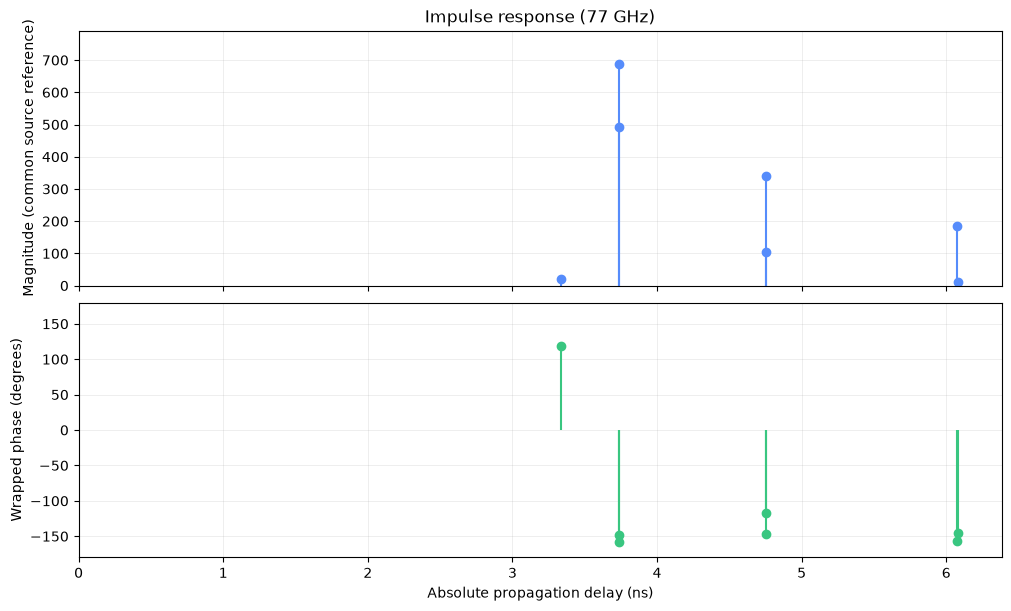

In [7]:
figure = rt.plot(result.impulse_response, output / "impulse_response.png")
display(figure)
plt.close(figure)

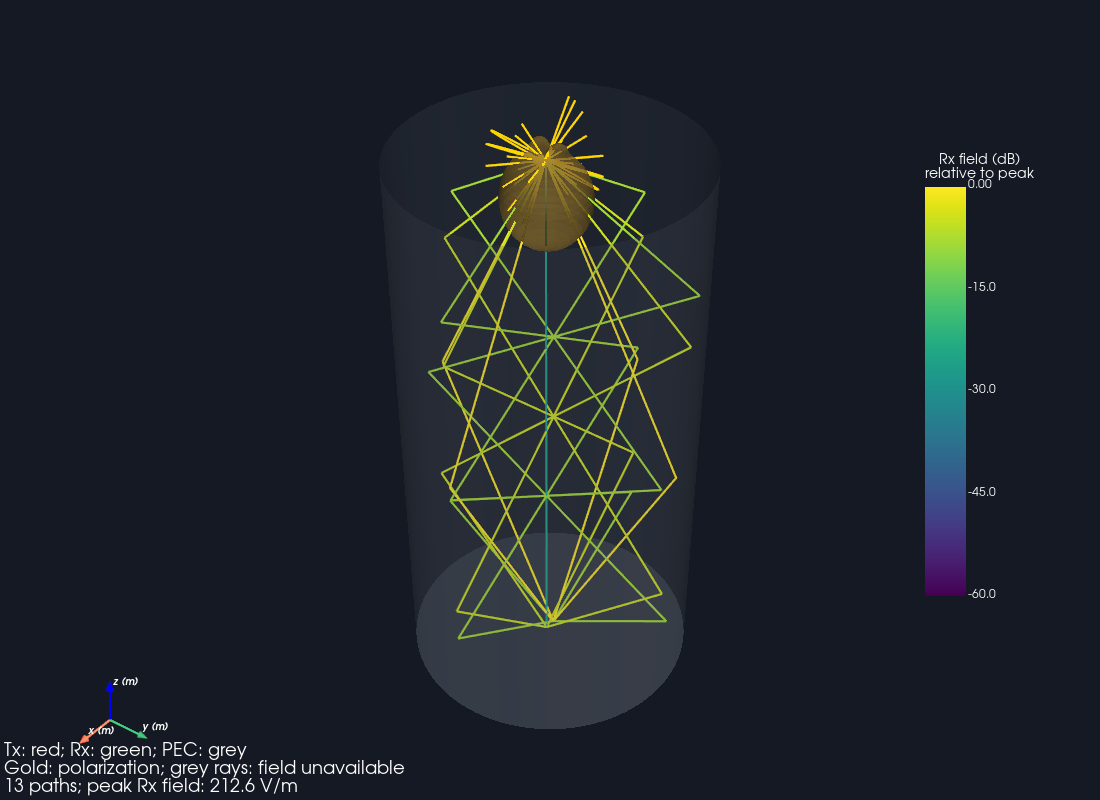

In [8]:
viewer = rt.visualize(result)
viewer.screenshot(str(output / "scene.png"))
display(Image(filename=str(output / "scene.png")))
viewer.close()

## Reload without retracing

The HDF5 file embeds both antenna patterns and the complete simulation. `rt.visualize(saved)` returns a PyVista Plotter for camera and scene customization. Use `viewer.show(jupyter_backend='static')` to display it inline, or `viewer.screenshot(path)` to save it, then `viewer.close()` when finished.

In [9]:
saved = rt.load_h5(output / "simulation.h5")
rt.frequency_response(saved.impulse_response)  # Complex channel response at the carrier.

(-1586.3772909799616-844.8107408516371j)